<a href="https://colab.research.google.com/github/2403a52208-sudo/NLP/blob/main/2403A52208_B09_Assg_11.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Create a small corpus

In [ ]:
# sample documents
d1 = "The morning sunrise over the mountains looked peaceful and filled the sky with golden light."
d2 = "A gentle breeze moved through the green trees while birds were singing beautifully in the quiet forest."
d3 = "The small café on the street served hot coffee and delicious pastries to the happy visitors."
d4 = "Students in the library were reading books and preparing carefully for their upcoming examinations."
# Put them together in a list
corpus = [d1, d2, d3, d4]

# Assign labels (positive/negative sentiment)
labels = ["positive", "negative", "positive", "negative"]

# Display corpus and labels
for i, (doc, label) in enumerate(zip(corpus, labels), start=1):
    print(f"d{i}: {doc} --> {label}")


d1: The morning sunrise over the mountains looked peaceful and filled the sky with golden light. --> positive
d2: A gentle breeze moved through the green trees while birds were singing beautifully in the quiet forest. --> negative
d3: The small café on the street served hot coffee and delicious pastries to the happy visitors. --> positive
d4: Students in the library were reading books and preparing carefully for their upcoming examinations. --> negative


Preprocess the corpus

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already present
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove stopwords
    tokens = [word for word in text.split() if word not in stop_words]
    return " ".join(tokens)

# Apply preprocessing to the corpus
clean_corpus = [preprocess(doc) for doc in corpus]

# Display results
for i, (original, cleaned) in enumerate(zip(corpus, clean_corpus), start=1):
    print(f"d{i} original: {original}")
    print(f"d{i} cleaned: {cleaned}\n")


d1 original: The morning sunrise over the mountains looked peaceful and filled the sky with golden light.
d1 cleaned: morning sunrise mountains looked peaceful filled sky golden light

d2 original: A gentle breeze moved through the green trees while birds were singing beautifully in the quiet forest.
d2 cleaned: gentle breeze moved green trees birds singing beautifully quiet forest

d3 original: The small café on the street served hot coffee and delicious pastries to the happy visitors.
d3 cleaned: small caf street served hot coffee delicious pastries happy visitors

d4 original: Students in the library were reading books and preparing carefully for their upcoming examinations.
d4 cleaned: students library reading books preparing carefully upcoming examinations



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Feature Extraction with TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Apply TF-IDF vectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_corpus)  # numerical feature matrix
y = labels  # sentiment labels

# Display vocabulary size and sample features
print("Vocabulary size:", len(vectorizer.vocabulary_))
print("Feature names:", list(vectorizer.vocabulary_.keys())[:10])  # show first 10 words
print("TF-IDF matrix shape:", X.shape)

Vocabulary size: 37
Feature names: ['morning', 'sunrise', 'mountains', 'looked', 'peaceful', 'filled', 'sky', 'golden', 'light', 'gentle']
TF-IDF matrix shape: (4, 37)


Train Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# With only 4 documents, a meaningful train-test split for evaluation is difficult.
# The previous split (test_size=0.5, random_state=42) resulted in y_train having only one class,
# which causes an error for Logistic Regression. For demonstration, we will train
# on the full dataset to ensure both classes are present.

# Initialize and train Logistic Regression on the full dataset
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X, y) # Train on full X and y

# Predict on the full dataset
y_pred = log_reg.predict(X)

# Evaluate
print("Accuracy:", accuracy_score(y, y_pred)) # Evaluate against full y
print("Confusion Matrix:\n", confusion_matrix(y, y_pred)) # Evaluate against full y

Accuracy: 1.0
Confusion Matrix:
 [[2 0]
 [0 2]]


Model Evaluation with Precision, Recall, F1

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


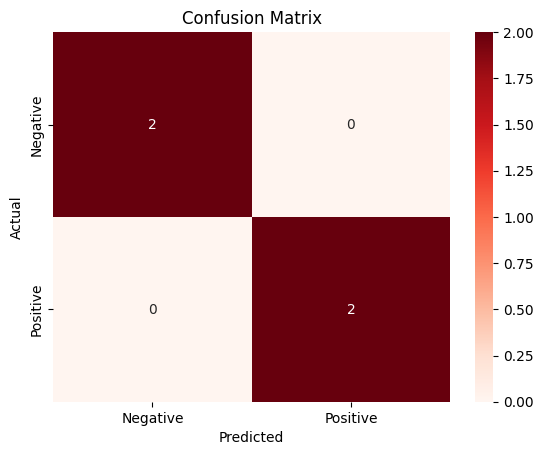

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluate predictions
print("Accuracy:", accuracy_score(y, y_pred))
print("Precision:", precision_score(y, y_pred, pos_label="positive"))
print("Recall:", recall_score(y, y_pred, pos_label="positive"))
print("F1-score:", f1_score(y, y_pred, pos_label="positive"))

# Confusion Matrix visualization
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()